In [27]:
import os

import torch
from torch.utils.data import Dataset, DataLoader  # Pytorch의 데이터셋 관련
from torchvision import transforms  # 전처리모듈

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

from lxml import etree

In [28]:

## 데이터 준비
# DATA_DIR = './_data/'
DATA_DIR = './data/Astrophysics'
## 이미지 전처리 관련 인스턴스
## - 이미지 텐서화 및 타입 설정

transform = transforms.Compose(
    [   
        # transforms.CenterCrop(640), 
        transforms.PILToTensor(),  ## PIL.ToTensor 사용 ToTensor와는 다름.
        ## PIL의 Image 객체를 텐서화
        transforms.ConvertImageDtype(dtype=torch.float)  ## Image 텐서 타입 설정
    ]
    
)


In [29]:
# class x_rayDataset(Dataset):
#     def __init__(self, image_root, xml_root, transform=None):
#         super().__init__()
#         self.image_root = image_root
#         self.xml_root = xml_root
#         self.transform = transform

#         self.flist = ['Firecracker', 'Hammer', 'NailClippers', 'Spanner', 'Thinner', 'ZippoOil']
#         self.class2idx = {name: idx+1 for idx, name in enumerate(self.flist)}
#         self.class2idx["unknown"] = 0

#         self.data = self._load_data()

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, index):
#         image, target = self.data[index]
#         if self.transform:
#             image = self.transform(image)
#         return image, target

#     def _load_data(self):
#         data = []
#         for dirpath, _, filenames in os.walk(self.image_root):
#             for fname in filenames:
#                 if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
#                     continue

#                 img_path = os.path.join(dirpath, fname)
#                 xml_path = os.path.join(self.xml_root, os.path.splitext(fname)[0] + ".xml")

#                 if not os.path.exists(xml_path):
#                     continue  # 해당 XML이 없으면 스킵

#                 # 이미지 로드
#                 image = Image.open(img_path).convert("RGB")

#                 # XML 파싱
#                 boxes, labels = [], []
#                 tree = etree.parse(xml_path)
#                 root = tree.getroot()

#                 for obj in root.findall('object'):
#                     label = obj.find('name').text
#                     label = label if label in self.flist else "unknown"
#                     bbox = obj.find('bndbox')
#                     xmin = int(bbox.find('xmin').text)
#                     ymin = int(bbox.find('ymin').text)
#                     xmax = int(bbox.find('xmax').text)
#                     ymax = int(bbox.find('ymax').text)
#                     boxes.append([xmin, ymin, xmax, ymax])
#                     labels.append(self.class2idx[label])

#                 target = {
#                     "boxes": torch.FloatTensor(boxes),
#                     "labels": torch.LongTensor(labels)
#                 }
#                 data.append([image, target])
#         return data


In [30]:
# class x_rayDataset(Dataset):
#     def __init__(self, image_paths, transform=None):
#         self.image_paths = image_paths
#         self.transform = transform

#         self.flist = ['Firecracker', 'Hammer', 'NailClippers', 'Spanner', 'Thinner', 'ZippoOil']
#         self.class_to_idx = {name: i for i, name in enumerate(self.flist)}
#         self.class_to_idx['Unknown'] = len(self.flist)

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         image_path = self.image_paths[idx]
#         print(image_path)
#         image = Image.open(image_path).convert("RGB")

#         # 대응되는 XML 파일 경로 추출
#         xml_path = image_path.replace('images', 'annotations').replace('.jpg', '.xml')

#         boxes, labels = self._parse_annotation(xml_path)

#         # transform 적용
#         if self.transform:
#             image = self.transform(image)

#         target = {
#             "boxes": torch.FloatTensor(boxes),
#             "labels": torch.LongTensor(labels)
#         }

#         return image, target

#     def _parse_annotation(self, xml_path):
#         tree = ET.parse(xml_path)
#         root = tree.getroot()

#         boxes = []
#         labels = []

#         for obj in root.findall("object"):
#             label = obj.find("name").text
#             label_idx = self.class_to_idx.get(label, self.class_to_idx['Unknown'])

#             bndbox = obj.find("bndbox")
#             xmin = float(bndbox.find("xmin").text)
#             ymin = float(bndbox.find("ymin").text)
#             xmax = float(bndbox.find("xmax").text)
#             ymax = float(bndbox.find("ymax").text)

#             boxes.append([xmin, ymin, xmax, ymax])
#             labels.append(label_idx)

#         return boxes, labels
    
#     def _load_data(self):
#         data = []

#         for image_path in self.image_paths:
#             # 이미지 로드
#             image = Image.open(image_path).convert("RGB")

#             # XML 어노테이션 파일 경로
#             xml_path = image_path.replace("images", "annotations").replace(".jpg", ".xml")

#             boxes, labels = [], []

#             # XML 파싱
#             tree = ET.parse(xml_path)
#             root = tree.getroot()

#             for obj in root.findall("object"):
#                 label = obj.find("name").text
#                 label_idx = self.class_to_idx.get(label, self.class_to_idx["Unknown"])

#                 bndbox = obj.find("bndbox")
#                 xmin = float(bndbox.find("xmin").text)
#                 ymin = float(bndbox.find("ymin").text)
#                 xmax = float(bndbox.find("xmax").text)
#                 ymax = float(bndbox.find("ymax").text)

#                 boxes.append([xmin, ymin, xmax, ymax])
#                 labels.append(label_idx)

#             # image_id는 생략하거나 필요 시 index로 대체 가능
#             target = {
#                 # 예: index를 사용한 image_id
#                 "image_id": torch.LongTensor([self.image_paths.index(image_path)]),
#                 "boxes": torch.FloatTensor(boxes),
#                 "labels": torch.LongTensor(labels)
#             }

#             data.append([image, target])

#         return data

In [31]:

# ## -------------------------------------------------------------
# ## 클래스이름 : X_rayDataset
# ## 부모클래스 : Dataset
# ## -------------------------------------------------------------
# class X_rayDataset(Dataset):
#     ## ---------------------------------------------------------
#     ## - 필수 오버라이딩 메서드
#     ## ---------------------------------------------------------
#     ## ---------------------------------------------------------
#     ## 메서드이름 : __init__
#     ## 매개변수들
#     # root: 데이터가 존재하는 경로
#     # train : 학습용 또는 검증용 식별 위한
#     # transform 이미지 전처리 인스턴스 지점
#     ## ---------------------------------------------------------
#     def __init__(self, root, train, transform=None):
#         super().__init__()
#         ## 실제 이미지 경로
#         directory = "train" if train else "val"

#         ## 이미지 내의 존재 객체 정보 추출.
#         annotations = os.path.join(root,
#                                    "Annotation",
#                                    f"coco_astrophysics.json")

#         self.coco = COCO(annotations)
#         ## train/val_annotation.json 읽어서 dict로 저장 
#         # - self.dataset
#         # - self.anns 이미지별 부가정보들
#         # - self.cats 데이터셋의 카테고리 정보
#         # - self.imgs 이미지

#         self.iamge_path = os.path.join(root, directory)
#         self.transform = transform

#         # 클래스 내부에서만 사용되는 메서드 호출 self.~~
#         self.categories = self._get_categories()  # 해당 데이터셋의 카테고리 IDX_TO_NAME
#         self.data = self._load_data()
            
            
#     ## ---------------------------------------------------------
#     ## 메서드이름: __getitem__
#     ## 매개변수들: 특정 데이터 인덱스
#     ## 반환결과값: 인덱스에 해당하는 이미지와 타겟 반환
#     ## ---------------------------------------------------------
#     def __getitem__(self, index):
#         image, target = self.data[index]
#         if self.transform:
#             image = self.transform(image)
#         return image, target

#     ## ---------------------------------------------------------
#     ## 메서드이름: __len__
#     ## 매개변수들: 없음
#     ## 반환결과값: 데이터 갯수 반환
#     ## ---------------------------------------------------------
#     def __len__(self):
#         return len(self.data)

#     ## ---------------------------------------------------------
#     ## - 사용자 정의 메서드
#     ## ---------------------------------------------------------
#     ## ---------------------------------------------------------
#     ## 메서드기능: 정수 맵핑 카테고리 반환 내장 메서드
#     ## 메서드이름: _get_categories
#     ## 매개변수들: 없음
#     ## 반환결과값: 정수 맵핑된 카테고리 Dict
#     ## ---------------------------------------------------------
#     def _get_categories(self):
#         categories = {0: "background"}
#         for category in self.coco.cats.values():
#             categories[category["id"]] = category["name"]
#         return categories

#     ## ---------------------------------------------------------
#     ## 메서드기능: 데이터셋 이미지와 이미지 정보 타겟 반환 내장 메서드
#     ## 메서드이름: _load_data
#     ## 매개변수들: 없음
#     ## 반환결과값: 이미지데이터와 타겟을 리스트로 담고 있는 리스트
#     ## ---------------------------------------------------------
#     def _load_data(self):
#         data = []
#         for _id in self.coco.imgs:
#             ## 이미지 데이터 로딩
#             file_name = self.coco.loadImgs(_id)[0]["file_name"]
#             image_path = os.path.join(self.iamge_path, file_name)

#             # raw 데이터 추출.
#             image = Image.open(image_path).convert("RGB")

#             ## 이미지 내 객체의 위치와 이미지 클래스 저장
#             boxes, labels = [], []
#             ## 이미지에 연동된 어노테이션 리스트 추출
#             anns = self.coco.loadAnns(self.coco.getAnnIds(_id))
#             ## 이미지 내에 객체 위치와 카테고리 정보 추출
#             for ann in anns:
#                 x, y, w, h = ann["bbox"]
#                 boxes.append([x, y, x + w, y + h])

#                 labels.append(ann["category_id"])
#             ## 이미지의 타겟 정보 즉, 아이디, 박스위치, 클래스 정보
#             target = {
#                 "image_id": torch.LongTensor([_id]),
#                 "boxes": torch.FloatTensor(boxes),
#                 "labels": torch.LongTensor(labels)
#             }
#             data.append([image, target])
#         return data


In [32]:
class x_rayDataset(Dataset):
    def __init__(self, image_root, xml_root, transform=None):
        super().__init__()
        self.image_root = image_root
        self.xml_root = xml_root
        self.transform = transform

        self.flist = ['Firecracker', 'Hammer', 'NailClippers', 'Spanner', 'Thinner', 'ZippoOil']
        self.class2idx = {name: idx+1 for idx, name in enumerate(self.flist)}
        self.class2idx["unknown"] = 0

        self.data = self._load_metadata()  # 이미지 경로와 XML 경로만 저장

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path, xml_path = self.data[index]
        image = Image.open(img_path).convert("RGB")

        # XML 파싱
        boxes, labels = [], []
        tree = etree.parse(xml_path)
        root = tree.getroot()

        for obj in root.findall('object'):
            label = obj.find('name').text
            label = label if label in self.flist else "unknown"
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.class2idx[label])

        target = {
            "boxes": torch.FloatTensor(boxes),
            "labels": torch.LongTensor(labels)
        }

        if self.transform:
            image = self.transform(image)

        return image, target

    def _load_metadata(self):
        data = []
        for dirpath, _, filenames in os.walk(self.image_root):
            for fname in filenames:
                if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img_path = os.path.join(dirpath, fname)
                xml_path = os.path.join(self.xml_root, os.path.splitext(fname)[0] + ".xml")

                if not os.path.exists(xml_path):
                    continue  # 해당 XML이 없으면 스킵

                data.append((img_path, xml_path))
        return data


In [33]:

trainDS = x_rayDataset(
    image_root='./data/Astrophysics/',
    ## train image 경로
    xml_root=r"./data/Annotation/Pascal/Astrophysics/",
    ## train xml 경로
    transform=transform
)
validDS = x_rayDataset(
    image_root='./data/testData/',
    ## test image 경로
    xml_root=r"./data/Annotation/Eval/Label/Pascal/AstroPhysics/",
    ## test xml 경로
    transform=transform
)

img, target = trainDS[0]
print(target)
print(f'[trainDS] 개수 : {len(trainDS)}개 ')
print(f'[validDS] 개수  : {len(validDS)}개 ')

{'boxes': tensor([[1209.,  396., 1251.,  473.]]), 'labels': tensor([1])}
[trainDS] 개수 : 3300개 
[validDS] 개수  : 680개 


In [34]:
import os

def remove_orphan_xml_files(image_root, xml_root, image_extensions=('.jpg', '.jpeg', '.png')):
    # 이미지 파일 이름 (확장자 제외) 목록 만들기
    image_names = set()
    for dirpath, _, filenames in os.walk(image_root):
        for fname in filenames:
            if fname.lower().endswith(image_extensions):
                name_wo_ext = os.path.splitext(fname)[0]
                image_names.add(name_wo_ext)

    # XML 파일 중 이미지가 없는 것 삭제
    deleted_count = 0
    for dirpath, _, filenames in os.walk(xml_root):
        for fname in filenames:
            if not fname.lower().endswith('.xml'):
                continue

            name_wo_ext = os.path.splitext(fname)[0]
            if name_wo_ext not in image_names:
                xml_path = os.path.join(dirpath, fname)
                os.remove(xml_path)
                deleted_count += 1
                print(f"🗑️ 삭제됨: {xml_path}")

    print(f"\n✅ 총 {deleted_count}개의 XML 파일이 삭제되었습니다.")

In [35]:
remove_orphan_xml_files('./data/Astrophysics/', "./data/Annotation/Pascal/Astrophysics/")
remove_orphan_xml_files('./data/testData/', "./data/Annotation/Eval/Label/Pascal/AstroPhysics/")



✅ 총 0개의 XML 파일이 삭제되었습니다.

✅ 총 0개의 XML 파일이 삭제되었습니다.


In [36]:
## 배치 데이터 생성 함수
## ---------------------------------------------------------
## 함수기능 : 개별 샘플을 미니배치로 결합하는 역할
## 함수이름 : collator
## 매개변수 : 배치크기
## 반환결과 : 배치크기만큼 연결된 데이터
## ---------------------------------------------------------
def collator(batch):
    return tuple(zip(*batch))

In [37]:
## 클래스 변환 Dict 생성
idx2class ={value:key for key, value in trainDS.class2idx.items()}
IDX_TO_CATEGORY = idx2class
print(IDX_TO_CATEGORY)
## 학습용 테스트용 데이터 확인
print(f'[trainDS] 개수 : {len(trainDS)}개 ')
print(f'[validDS] 개수  : {len(validDS)}개 ')
## 학습용 데이터셋에서 이미지 1개
imgTS, targetDict = trainDS[0]  ## <== __getitem__(indx)
print(imgTS.shape, targetDict.keys())

{1: 'Firecracker', 2: 'Hammer', 3: 'NailClippers', 4: 'Spanner', 5: 'Thinner', 6: 'ZippoOil', 0: 'unknown'}
[trainDS] 개수 : 3300개 
[validDS] 개수  : 680개 
torch.Size([3, 1080, 1920]) dict_keys(['boxes', 'labels'])


lx, ly, w, h => (1209, 396, 42, 77)


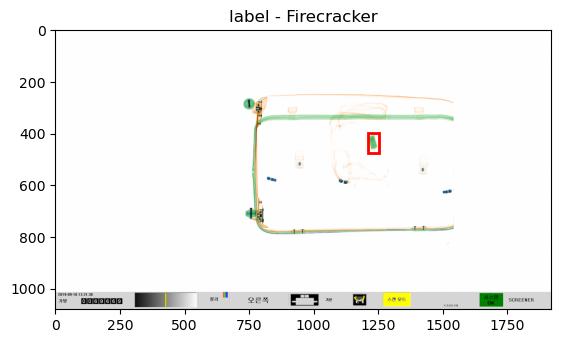

In [38]:

# - 라벨 정보 추출
label = targetDict['labels'].item()

# - 객체 위치 정보 추출
lx, ly, rx, ry = [round(data.item()) for data in targetDict['boxes'].reshape(-1)]
w, h = rx - lx, ry - ly

print(f'lx, ly, w, h => {lx, ly, w, h}')
## 시각화 및 바운딩 박스
plt.imshow(imgTS.permute(1, 2, 0))
plt.title(f'label - {IDX_TO_CATEGORY[label]}')

## 바운딩 박스 추가
ax = plt.gca()  #- get current axis
ax.add_patch(patches.Rectangle((lx, ly), w, h, color='red', linewidth=2, fill=False))

plt.show()

In [39]:

TBATCH_SIZE = 400
VBATCH_SIZE = 100
NUM_WORKER = 4

In [40]:
TRAIN_DL = DataLoader( trainDS, batch_size=TBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator,num_workers=NUM_WORKER)
VALID_DL  = DataLoader( validDS,  batch_size=VBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator ,num_workers=NUM_WORKER)

In [41]:
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNet_ResNet50_FPN_Weights, ResNet50_Weights


In [42]:
# weights 설정
WEIGHTS = RetinaNet_ResNet50_FPN_Weights.DEFAULT

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# 모델 로딩 (pretrained backbone 포함)
MODEL = retinanet_resnet50_fpn(
    weights=None,  # 전체 모델은 초기화
    weights_backbone=ResNet50_Weights.DEFAULT,
    num_classes=7  # 여기서 원하는 클래스 수 지정
).to(DEVICE)

In [43]:
from torch import optim


params = [p for p in MODEL.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

EPOCHS = 1

# 로그 저장
train_losses, train_accs, train_precisions, train_recalls, train_f1s = [], [], [], [], []
valid_accs, valid_precisions, valid_recalls, valid_f1s = [], [], [], []

# Early stopping 관련 변수
best_loss = float('inf')
patience = 0
early_stop_patience = 5  # 조기 종료 조건

for epoch in range(EPOCHS):
    MODEL.train()
    epoch_loss = 0.0
    all_preds, all_labels = [], []

    for idx, (images, targets) in enumerate(TRAIN_DL):
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = MODEL(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        # 예측 저장
        MODEL.eval()
        with torch.no_grad():
            outputs = MODEL(images)

        for output, target in zip(outputs, targets):
            scores = output["scores"].detach().cpu()
            labels_pred = output["labels"].detach().cpu()
            labels_true = target["labels"].detach().cpu()

            keep = scores > 0.5
            labels_pred = labels_pred[keep]

            all_preds.extend(labels_pred.numpy().tolist())
            all_labels.extend(labels_true.numpy().tolist())

        MODEL.train()

    # 평균 손실
    epoch_loss /= len(TRAIN_DL)
    train_losses.append(epoch_loss)

    # 훈련 지표 계산
    if all_preds:
        acc = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    else:
        acc = precision = recall = f1 = 0.0

    train_accs.append(acc)
    train_precisions.append(precision)
    train_recalls.append(recall)
    train_f1s.append(f1)

    # ------------------ 검증 ------------------
    MODEL.eval()
    valid_preds, valid_labels = [], []

    with torch.no_grad():
        for images, targets in VALID_DL:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            outputs = MODEL(images)

            for output, target in zip(outputs, targets):
                scores = output["scores"].detach().cpu()
                labels_pred = output["labels"].detach().cpu()
                labels_true = target["labels"].detach().cpu()

                keep = scores > 0.5
                labels_pred = labels_pred[keep]

                valid_preds.extend(labels_pred.numpy().tolist())
                valid_labels.extend(labels_true.numpy().tolist())

    if valid_preds:
        val_acc = accuracy_score(valid_labels, valid_preds)
        val_precision = precision_score(valid_labels, valid_preds, average='macro', zero_division=0)
        val_recall = recall_score(valid_labels, valid_preds, average='macro', zero_division=0)
        val_f1 = f1_score(valid_labels, valid_preds, average='macro', zero_division=0)
    else:
        val_acc = val_precision = val_recall = val_f1 = 0.0

    valid_accs.append(val_acc)
    valid_precisions.append(val_precision)
    valid_recalls.append(val_recall)
    valid_f1s.append(val_f1)

    print(f"[Epoch {epoch+1}] Loss: {epoch_loss:.4f} | Train Acc: {acc:.4f} | Val Acc: {val_acc:.4f}")
    print(f"   Train → Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(f"   Valid → Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

    # learning rate scheduler
    lr_scheduler.step()

    # Early Stopping & Model Save
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        patience = 0
        torch.save(MODEL.state_dict(), f"res_retina_{epoch+1}_{best_loss:.4f}.pth")
        print(f"✅ 모델 저장됨 (loss 개선됨: {best_loss:.4f})")
    else:
        patience += 1
        print(f"⚠️ loss 개선 없음 (patience {patience}/{early_stop_patience})")

    if patience >= early_stop_patience:
        print("🛑 Early stopping triggered.")
        break


In [ ]:
# from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# # 성능 기록용 리스트
# train_losses = []
# train_accs = []
# train_precisions = []
# train_recalls = []
# train_f1s = []

# for epoch in range(EPOCHS):
#     MODEL.train()
#     epoch_loss = 0.0

#     # 모든 예측, 정답 모으기 위한 리스트
#     all_preds = []
#     all_labels = []

#     for idx, (images, targets) in enumerate(TRAIN_DL):
#         images = [img.to(DEVICE) for img in images]
#         targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

#         # forward: 손실 반환
#         loss_dict = MODEL(images, targets)
#         losses = sum(loss for loss in loss_dict.values())

#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()

#         epoch_loss += losses.item()

#         # 평가용으로 forward: 예측값 반환 (inference 모드)
#         MODEL.eval()
#         with torch.no_grad():
#             outputs = MODEL(images)

#         # RetinaNet은 한 이미지에 여러 예측이 나옴 → confidence score 높은 것만 선택
#         for output, target in zip(outputs, targets):
#             pred_labels = output["labels"].detach().cpu()
#             true_labels = target["labels"].detach().cpu()

#             # IoU 또는 confidence 기준 필터링 (여기선 간단하게 confidence > 0.5)
#             scores = output["scores"].detach().cpu()
#             mask = scores > 0.5
#             pred_labels = pred_labels[mask]

#             # 평가지표 계산을 위해 라벨 저장
#             all_preds.extend(pred_labels.numpy().tolist())
#             all_labels.extend(true_labels.numpy().tolist())

#         MODEL.train()

#     # 에포크당 평균 손실
#     epoch_loss /= len(TRAIN_DL)
#     train_losses.append(epoch_loss)

#     # 정확도, 정밀도, 재현율, F1 계산
#     if all_preds:
#         acc = accuracy_score(all_labels, all_preds)
#         precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
#         recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
#         f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
#     else:
#         acc = precision = recall = f1 = 0.0  # 예측이 없을 경우

#     train_accs.append(acc)
#     train_precisions.append(precision)
#     train_recalls.append(recall)
#     train_f1s.append(f1)

#     print(f"[Epoch {epoch+1}] Loss: {epoch_loss:.4f} | Acc: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

#     # 스케줄러 step
#     lr_scheduler.step()

#     # 모델 저장
#     torch.save(MODEL.state_dict(), f"model_epoch_{epoch+1}.pth")


In [ ]:
# ## 학습 진행
# for epoch in range(1):
#     cost = 0.0
#     for idx, (images, targets) in enumerate(TRAIN_DL):
#         ## GPU에 이미지와 타겟 정보 위치
#         images = list(image.to(DEVICE) for image in images)
#         targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
#         if idx == 4:
#             break
        
#         ## 모델 학습 ==> 이미지와 이미지 내의 객체 정보 ( 클래스, 박스) 전달
#         ## - vgg16 => Feature Map --> RPN: BBOX Reg 손실값
#         ## - FasterRCNN => 클래스 분류 손실값, 객체 위치 회귀 손실값
#         ## - 객체 존재 여부 손실값
#         loss_dict = MODEL(images, targets)
#         ## - 모델 구성에서 계산된 손실값의 합계
#         losses = sum(loss for loss in loss_dict.values())

#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()

#         cost += losses

#     lr_scheduler.step()
#     cost = cost / len(TRAIN_DL)
#     print(f"Epoch : {epoch+1:4d}, Cost : {cost:.3f}")

In [ ]:
# ## 모델 관련 모듈 로딩
# from torchvision.models import vgg16, VGG16_Weights
# from torchvision.models.detection import RetinaNet
# from torchvision.models._utils import IntermediateLayerGetter


In [ ]:

# ## --------------------------------------------------------------
# ## 모델 관련 설정들
# ## --------------------------------------------------------------
# ## - Backbone Network 관련
# WEIGHTS = VGG16_Weights.DEFAULT
# # Get VGG16 features
# backbone = vgg16(weights=WEIGHTS).features
# # 특징 추출 레이어 정의 (FPN 사용 시)
# # VGG16의 경우, 풀링(pooling) 블록 이후의 일반적인 레이어들이 FPN을 위한 특징 추출에 사용됩니다.
# # 이름들은 Sequential 특징 블록에 있는 모듈들의 이름과 일치합니다.
# # 원하는 레이어의 정확한 이름/인덱스를 찾으려면 백본 구조를 확인해야 할 수 있습니다 (예: 백본 출력).
# # 풀링 이전의 마지막 몇몇 Conv2d 레이어 또는 특정 풀링 레이어 이후의 레이어 인덱스를 사용하는 예시입니다. FPN이 특정 해상도 레벨을 기대하기 때문입니다.
# # VGG 아키텍처의 일반적인 특징에 기반하여, 인덱스 16, 23, 30 근처의 레이어들이 컨볼루션 블록 끝 부분 또는 풀링 레이어 이후에 해당될 수 있습니다.
# # VGG를 FPN과 함께 사용할 때 일반적인 방법은 마지막 몇몇 풀링 레이어 이전의 특징을 사용하는 것입니다.
# # 시연을 위해 몇 가지 그럴듯한 레이어 인덱스를 선택했습니다. 실제 인덱스는 약간 다를 수 있습니다.

# return_layers = {'23': '0', '25': '1', '27': '2', '29': '3', '30': '4'} # Example indices

# # Using IntermediateLayerGetter to get features from specified layers
# backbone = IntermediateLayerGetter(backbone, return_layers=return_layers)

# # Define the number of output channels for the backbone's features.
# # For VGG16 features used with FPN, the number of channels for the selected layers is typically 512.
# backbone.out_channels = 512

In [ ]:

# ## 학습관련 설정 값
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# EPOCHS = 10
# TBATCH_SIZE = 4
# VBATCH_SIZE = 1

In [ ]:


# # Initialize the RetinaNet model
# # num_classes = 3 (background, dog, cat)
# # MODEL = RetinaNet(
# #     backbone=backbone,
# #     num_classes=3  # +1 for background in some definitions, but torchvision's RetinaNet handles it
# # ).to(DEVICE)


# ## 데이터셋 관련 인스턴스 생성
# TRAIN_DL = DataLoader(trainDS, batch_size=TBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator)
# VALID_DL = DataLoader(validDS, batch_size=VBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator)
# print(TRAIN_DL)

In [ ]:
# from torch import optim

# params = [p for p in MODEL.parameters() if p.requires_grad]
# optimizer = optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
# lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
# ## 학습 진행
# for epoch in range(1): # Reduced epochs for demonstration
#     cost = 0.0
#     MODEL.train() # Set model to training mode
#     for idx, (images, targets) in enumerate(TRAIN_DL):
#         ## GPU에 이미지와 타겟 정보 위치
#         images = list(image.to(DEVICE) for image in images)
#         targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
#         if idx == 4: # Reduced iterations for demonstration
#              break

#         ## 모델 학습 ==> 이미지와 이미지 내의 객체 정보 ( 클래스, 박스) 전달
#         loss_dict = MODEL(images, targets)
#         ## - 모델 구성에서 계산된 손실값의 합계
#         losses = sum(loss for loss in loss_dict.values())

#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()

#         cost += losses.item() # Use .item() to get the scalar value of the loss

#     lr_scheduler.step()
#     cost = cost / (idx + 1) # Calculate average cost over the iterations
#     print(f"Epoch : {epoch + 1:4d}, Cost : {cost:.3f}")


Epoch :    1, Cost : 1.432


In [ ]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.transforms.functional import to_pil_image

## 객체에 박스 그리기.
def draw_bbox(ax, box, text, color):
    ax.add_patch(
        plt.Rectangle(
            xy=(box[0], box[1]),
            width=box[2] - box[0],
            height=box[3] - box[1],
            fill=False,
            edgecolor=color,
            linewidth=2,
        )
    )
    #객체 위치에 라벨 달기
    ax.annotate(
        text=text,
        xy=(box[0] - 5, box[1] - 5),
        color=color,
        weight="bold",
        fontsize=13,
    )
 
 
## 검증진행
## 예측 결과에 대한 신뢰도. 0.5 이상이면 중간 이상의 신뢰도
threshold = 0.5
categories = idx2class
with torch.no_grad():
    MODEL.eval()
    idx = 0
    for images, targets in VALID_DL:
        idx += 1
        if idx == 5:
            break
        # 예측진행
        images = [image.to(DEVICE) for image in images] ## GPU적용. cpu면 없어도됨
        
        outputs = MODEL(images)
        # 각 이미지에 대한 예측 결과 반환
        ## -> boxes : 예측된 경계상자 좌표
        ## -> labels: 예측 박스의 클래스 인덱스
        ## -> scores : 예측 박스에 대한 신뢰도(확률) 점수, 값의 범위는 0.0~1.0
        ## 예측 객체 위치, 라벨, 점수 저장 변수들
        boxes = outputs[0]["boxes"].to(DEVICE).numpy()
        labels = outputs[0]["labels"].to(DEVICE).numpy()
        scores = outputs[0]["scores"].to(DEVICE).numpy()
        
        
        boxes = boxes[scores >= threshold].astype(np.int32)
        labels = labels[scores >= threshold]
        scores = scores[scores >= threshold]

        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1)
        plt.imshow(to_pil_image(images[0]))

        for box, label, score in zip(boxes, labels, scores):
            draw_bbox(ax, box, f"{categories[label]} - {score:.4f}", "red")

        tboxes = targets[0]["boxes"].numpy()
        tlabels = targets[0]["labels"].numpy()
        for box, label in zip(tboxes, tlabels):
            draw_bbox(ax, box, f"{categories[label]}", "blue")
            
        plt.show()

In [ ]:
## 검증 진행에 따른 성능평가
## -> 정확도, 정밀도, 재현율


import numpy as np
from pycocotools.cocoeval import COCOeval


with torch.no_grad():
    MODEL.eval()
    coco_detections = []
    
    idx = 0
    for images, targets in VALID_DL:
        idx += 1
        if idx == 5:
            break
        images = [img.to(DEVICE) for img in images]
        outputs = MODEL(images)
        ## 예측값
        
        for i in range(len(targets)):
            ## 정답
            image_id = targets[i]["image_id"].data.cpu().numpy().tolist()[0]
            
            ## 예측값
            boxes = outputs[i]["boxes"].data.cpu().numpy()
            boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
            boxes[:, 3] = boxes[:, 3] - boxes[:, 1]
            scores = outputs[i]["scores"].data.cpu().numpy()
            labels = outputs[i]["labels"].data.cpu().numpy()

            for instance_id in range(len(boxes)):
                box = boxes[instance_id, :].tolist()
                prediction = np.array(
                    [
                        image_id,
                        box[0],
                        box[1],
                        box[2],
                        box[3],
                        float(scores[instance_id]),
                        int(labels[instance_id]),
                    ]
                )
                coco_detections.append(prediction)

    ##예측정보 저장
    coco_detections = np.asarray(coco_detections)
    coco_gt = VALID_DL.dataset.coco()                  ## 정답
    coco_dt = coco_gt.loadRes(coco_detections)      ## 예측
    
    coco_evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_evaluator.evaluate()
    coco_evaluator.accumulate()
    coco_evaluator.summarize()
    
    ## 성능평가
    ## 정답박스와 예측박스 비교방식 ==> IOU
    ## p 533
    

TypeError: 'COCO' object is not callable